#### Préparation ML

In [78]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [79]:
# Chargement des données

# Données clean
df = pd.read_csv("../data/processed/marketing_clean.csv")
print(df.head())

     tv      radio  social_media influencer       sales  total_budget  \
0  16.0   6.566231      2.907983       Mega   54.732757     25.474214   
1  13.0   9.237765      2.409567       Mega   46.677897     24.647332   
2  41.0  15.886446      2.913410       Mega  150.177829     59.799856   
3  83.0  30.020028      6.922304       Mega  298.246340    119.942332   
4  15.0   8.437408      1.405998      Micro   56.594181     24.843406   

   tv_share  radio_share  social_media_share       roi     tv_radio  \
0  0.628086     0.257760            0.114154  2.148555   105.059693   
1  0.527440     0.374798            0.097762  1.893832   120.090939   
2  0.685620     0.265660            0.048719  2.511341   651.344287   
3  0.691999     0.250287            0.057714  2.486581  2491.662346   
4  0.603782     0.339624            0.056594  2.278036   126.561115   

    tv_social  radio_social  sales_per_tv  sales_per_radio  sales_per_social  \
0   46.527724     19.094486      3.420797         8.33

In [80]:
# Vérification des données

# Vérifier les types de variables et les valeurs manquantes
print(df.info())

# Vérifier s’il reste des valeurs nulles
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   tv                  4572 non-null   float64
 1   radio               4572 non-null   float64
 2   social_media        4572 non-null   float64
 3   influencer          4572 non-null   object 
 4   sales               4572 non-null   float64
 5   total_budget        4572 non-null   float64
 6   tv_share            4572 non-null   float64
 7   radio_share         4572 non-null   float64
 8   social_media_share  4572 non-null   float64
 9   roi                 4572 non-null   float64
 10  tv_radio            4572 non-null   float64
 11  tv_social           4572 non-null   float64
 12  radio_social        4572 non-null   float64
 13  sales_per_tv        4572 non-null   float64
 14  sales_per_radio     4572 non-null   float64
 15  sales_per_social    4572 non-null   float64
 16  influe

Le dataset contient 4572 lignes et 19 variables.
Aucune valeur manquante n’est présente, ce qui indique que les données sont propres et bien préparées.

La majorité des variables sont numériques, ce qui est adapté aux modèles de machine learning.
La variable influencer est correctement encodée, ce qui permet son utilisation directe dans les modèles.

In [81]:
# Variable cible
y = df["sales"]

# Variables explicatives
X = df.drop(columns=["sales", "roi", "influencer"]) # suppression

print(X.head())

     tv      radio  social_media  total_budget  tv_share  radio_share  \
0  16.0   6.566231      2.907983     25.474214  0.628086     0.257760   
1  13.0   9.237765      2.409567     24.647332  0.527440     0.374798   
2  41.0  15.886446      2.913410     59.799856  0.685620     0.265660   
3  83.0  30.020028      6.922304    119.942332  0.691999     0.250287   
4  15.0   8.437408      1.405998     24.843406  0.603782     0.339624   

   social_media_share     tv_radio   tv_social  radio_social  sales_per_tv  \
0            0.114154   105.059693   46.527724     19.094486      3.420797   
1            0.097762   120.090939   31.324374     22.259015      3.590607   
2            0.048719   651.344287  119.449817     46.283733      3.662874   
3            0.057714  2491.662346  574.551229    207.807760      3.593329   
4            0.056594   126.561115   21.089972     11.862980      3.772945   

   sales_per_radio  sales_per_social  influencer_Mega  influencer_Micro  \
0         8.33549

La variable cible retenue est `sales`, correspondant au volume de ventes à prédire.

Les variables explicatives regroupent les budgets marketing, les variables issues du feature engineering ainsi que les variables encodées liées au type d’influenceur.

La variable `roi` a été exclue afin d’éviter toute fuite de données, car elle est calculée à partir des ventes.

##### Train / Test Split

In [82]:
# Séparation des données en train et test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,       # 20% des données pour le test
    random_state=42      # pour reproductibilité
)

# Vérification des dimensions
print("Train shape :", X_train.shape)
print("Test shape :", X_test.shape)

Train shape : (3657, 16)
Test shape : (915, 16)


Le dataset a été divisé en deux parties :

80 % pour entraîner le modèle (3657 lignes)
20 % pour tester le modèle (915 lignes)

Cela permet d’entraîner le modèle sur certaines données, puis de vérifier ses performances sur de nouvelles données qu’il n’a jamais vues

### I- Machine Learning

#### 1- Regréssion lineaire

In [83]:
from sklearn.linear_model import LinearRegression

# Initialisation du modèle
model_lr = LinearRegression()

# Entraînement du modèle
model_lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


###### Prédictions + Évaluation

In [84]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np


# Prédictions sur le jeu de test

y_pred_lr = model_lr.predict(X_test)


# Calcul des métriques

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

# Résultats
print("RMSE :", round(rmse_lr, 2))
print("R² :", round(r2_lr, 4))

RMSE : 4.69
R² : 0.9974


Le niveau d’erreur reste faible au regard des valeurs de ventes observées.

Le coefficient R² indique que le modèle explique environ 99,74 % de la variation des ventes. Cela montre une relation très forte entre les variables marketing et les ventes.

#### 2- Random Forest Regressor

In [85]:
from sklearn.ensemble import RandomForestRegressor

# Modèle Random Forest

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Entraînement
rf_model.fit(X_train, y_train)

print("Random Forest entraîné avec succès sur les données d’apprentissage.")

Random Forest entraîné avec succès sur les données d’apprentissage.


###### Prédictions + Évaluation

In [86]:
# Prédictions
y_pred_rf = rf_model.predict(X_test)

# Métriques
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("RMSE :", round(rmse_rf, 2))
print("R² :", round(r2_rf, 4))



RMSE : 5.58
R² : 0.9963


Le modèle reste très performant et explique une grande partie de la variation des ventes.

Cependant, ses résultats sont légèrement inférieurs à ceux de la régression linéaire sur ce dataset.

#### 3- Gradient Boosting

In [87]:
from sklearn.ensemble import GradientBoostingRegressor


# Modèle Gradient Boosting

gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Entraînement
gb_model.fit(X_train, y_train)

print("Gradient Boosting entraîné avec succès.")

Gradient Boosting entraîné avec succès.


###### Prédictions + Évaluation

In [88]:
# Prédictions
y_pred_gb = gb_model.predict(X_test)

# Métriques
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("RMSE :", round(rmse_gb, 2))
print("R² :", round(r2_gb, 4))

RMSE : 3.91
R² : 0.9982


Le niveau d'erreur est plus faible et la capacité d'explication des ventes est encore meilleure par rapport aux autres modèles.

#### 4- Entraînement XGBoost

In [89]:
import xgboost
print("XGBoost disponible")

XGBoost disponible


In [90]:
from xgboost import XGBRegressor

# Modèle XGBoost

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

# Entraînement
xgb_model.fit(X_train, y_train)

print("XGBoost entraîné avec succès.")

XGBoost entraîné avec succès.


###### Prédictions + Évaluation

In [91]:
# Prédictions
y_pred_xgb = xgb_model.predict(X_test)

# Métriques
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("RMSE :", round(rmse_xgb, 2))
print("R² :", round(r2_xgb, 4))

RMSE : 4.85
R² : 0.9972


Les performances restent excellentes, avec une très forte capacité explicative.

Cependant, sur ce dataset précis, XGBoost ne dépasse pas les résultats obtenus par Gradient Boosting.

### II- Deep Learning

In [92]:
%pip install tensorflow


[notice] A new release of pip available: 22.3.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [93]:
import tensorflow as tf
print("TensorFlow disponible")

TensorFlow disponible


##### Préparation des données DL

In [94]:
from sklearn.preprocessing import StandardScaler


# Standardisation des variables

scaler = StandardScaler()

# Apprentissage sur train puis transformation
X_train_scaled = scaler.fit_transform(X_train)

# Transformation du test
X_test_scaled = scaler.transform(X_test)

print("Données standardisées avec succès.")

Données standardisées avec succès.


#### Construire le modèle MLP Régression

In [95]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam


# Modèle Deep Learning pour la régression
# Prédiction des ventes (sales)


mlp_reg = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation="relu"),
    Dense(1)  # sortie continue pour une régression
])

# Compilation du modèle
mlp_reg.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

# Résumé de l’architecture
mlp_reg.summary()

c:\Users\thelm\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

In [96]:
mlp_reg = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])

mlp_reg.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

Réseau de neurones dense composé de trois couches :

- une première couche cachée de 64 neurones
- une deuxième couche cachée de 32 neurones
- une couche de sortie avec 1 neurone pour prédire une valeur continue : les ventes

Le modèle contient 3 201 paramètres entraînables.

##### Architecture MLP

In [97]:
%pip install pydot graphviz

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [98]:

# Entraînement du modèle MLP de régression


history_reg = mlp_reg.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

print("MLP Régression entraîné avec succès.")

MLP Régression entraîné avec succès.


In [99]:
%pip install pydot

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [100]:
from tensorflow.keras.utils import plot_model
from IPython.display import Image, display
from pathlib import Path

# Chemin de sauvegarde de l'image
output_path = Path("mlp_regressor_architecture.png")

# Génération du schéma
plot_model(
    mlp_reg,
    to_file=str(output_path),
    show_shapes=True,
    show_layer_names=True,
    dpi=120
)

# Vérification puis affichage
if output_path.exists():
    display(Image(filename=str(output_path)))
else:
    print("Le fichier n'a pas été généré. Vérifie l'installation de pydot et graphviz.")

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
Le fichier n'a pas été généré. Vérifie l'installation de pydot et graphviz.


##### Courbe Loss

In [101]:
history = mlp_reg.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32
)

Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.6431 - mae: 0.7956 - val_loss: 2.3213 - val_mae: 0.7941
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0685 - mae: 0.6900 - val_loss: 2.0820 - val_mae: 0.7511
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.3253 - mae: 0.6679 - val_loss: 2.2320 - val_mae: 0.8113
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.2836 - mae: 0.6936 - val_loss: 2.0760 - val_mae: 0.7754
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0604 - mae: 0.7007 - val_loss: 1.9819 - val_mae: 0.7305
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8951 - mae: 0.6500 - val_loss: 1.7971 - val_mae: 0.7322
Epoch 7/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9713 - mae: 0.6661 - val_loss: 1.9507 - val_mae: 0.7488
Epoch 8/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9896 - mae: 0.6566 - val_loss: 1.7811 - val_mae: 0.7659
Epoch 9/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.968

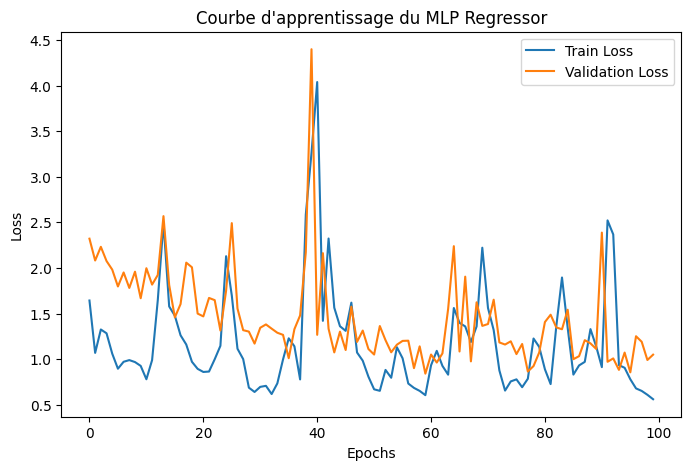

In [102]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Courbe d'apprentissage du MLP Regressor")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

On observe une diminution progressive de la loss au fil des epochs, ce qui montre que le modèle apprend efficacement les relations présentes dans les données.

In [103]:
# Prédictions du réseau de neurones

y_pred_mlp = mlp_reg.predict(X_test_scaled, verbose=0).flatten()

# Métriques
rmse_mlp = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
r2_mlp = r2_score(y_test, y_pred_mlp)

print("RMSE :", round(rmse_mlp, 2))
print("R² :", round(r2_mlp, 4))

RMSE : 2.21
R² : 0.9994


Ces performances sont supérieures aux modèles de machine learning testés précédemment.

Le niveau d’erreur est très faible et le modèle explique presque totalement la variation des ventes.

##### Scatter plot

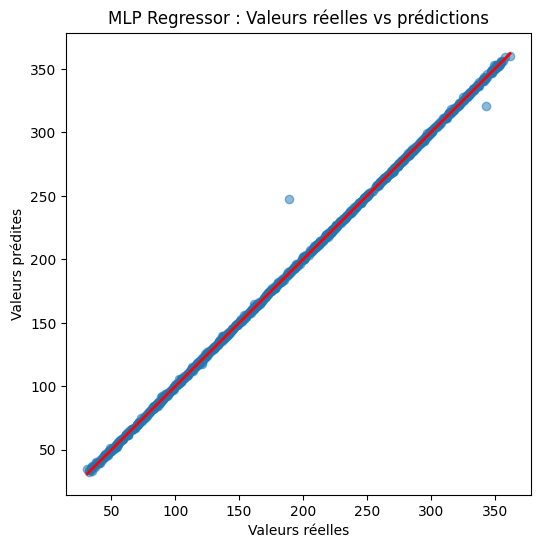

In [104]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_mlp, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("MLP Regressor : Valeurs réelles vs prédictions")
plt.show()

La quasi-totalité des points se situe directement sur la diagonale rouge.
Cela signifie que les prédictions du modèle sont extrêmement proches des valeurs réelles.
Quelques observations légèrement éloignées de la diagonale existent, mais elles restent marginales.
Ce graphique confirme visuellement la très forte performance du modèle.


##### Histogramme des erreurs (résidus)

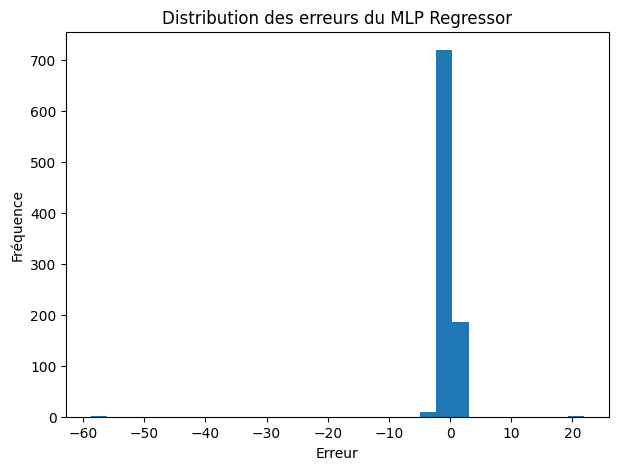

In [105]:
errors = y_test - y_pred_mlp.flatten()

plt.figure(figsize=(7,5))
plt.hist(errors, bins=30)
plt.title("Distribution des erreurs du MLP Regressor")
plt.xlabel("Erreur")
plt.ylabel("Fréquence")
plt.show()

Les erreurs sont très fortement concentrées autour de zéro. (Modèle commet peu d'erreur)

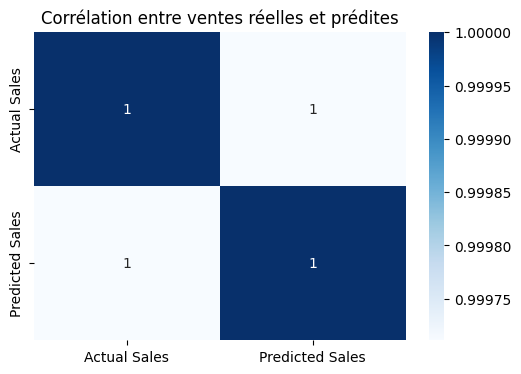

In [106]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

results_df = pd.DataFrame({
    "Actual Sales": y_test,
    "Predicted Sales": y_pred_mlp.flatten()
})

corr_matrix = results_df.corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap="Blues")
plt.title("Corrélation entre ventes réelles et prédites")
plt.show()

#### Création de la cible classification

In [107]:
# Création d'une cible binaire :
# High = ventes au-dessus de la médiane
# Low = ventes en dessous ou égales


median_sales = df["sales"].median()

df["performance"] = (df["sales"] > median_sales).astype(int)

print("Répartition des classes :")
print(df["performance"].value_counts())

Répartition des classes :
performance
0    2289
1    2283
Name: count, dtype: int64


Une nouvelle variable cible nommée `performance` a été créée afin de distinguer les campagnes les plus performantes des moins performantes.

La séparation a été réalisée à partir de la médiane des ventes :

- 1 : ventes supérieures à la médiane (campagnes performantes)
- 0 : ventes inférieures ou égales à la médiane

La répartition des classes est équilibrée, ce qui constitue un contexte favorable pour entraîner un modèle de classification.

In [108]:
from sklearn.model_selection import train_test_split


# Variable cible classification

y_class = df["performance"]

# Variables explicatives
X_class = df.drop(columns=["sales", "roi", "influencer", "performance"])

# Séparation train / test
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

print("Train shape :", X_train_c.shape)
print("Test shape :", X_test_c.shape)

Train shape : (3657, 16)
Test shape : (915, 16)


- 3657 observations pour l’entraînement
- 915 observations pour le test

L’option `stratify` a été utilisée afin de conserver la même proportion de classes dans les deux ensembles.

In [109]:
# Standardisation des variables

scaler_c = StandardScaler()

X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

print("Données classification standardisées avec succès.")

Données classification standardisées avec succès.


In [110]:
# Réseau de neurones pour classification binaire

mlp_clf = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_c_scaled.shape[1],)),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")  # sortie binaire
])

# Compilation
mlp_clf.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Résumé
mlp_clf.summary()

c:\Users\thelm\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

Le modèle Deep Learning de classification repose sur trois couches :

- une couche cachée de 64 neurones
- une couche cachée de 32 neurones
- une couche de sortie avec 1 neurone et activation sigmoid

La fonction sigmoid permet de produire une probabilité comprise entre 0 et 1 afin de classer les campagnes en deux catégories : performante ou non performante.

In [111]:

# Entraînement du réseau de neurones classification

history_clf = mlp_clf.fit(
    X_train_c_scaled,
    y_train_c,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

print("MLP Classification entraîné avec succès.")

MLP Classification entraîné avec succès.


Répartition des classes :
performance
0    2289
1    2283
Name: count, dtype: int64


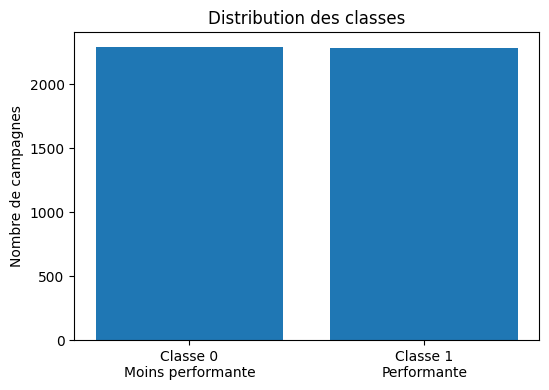

In [112]:
# Distribution des classes

import matplotlib.pyplot as plt

# Vérification distribution classes
class_counts = df["performance"].value_counts().sort_index()

print("Répartition des classes :")
print(class_counts)

plt.figure(figsize=(6,4))
plt.bar(
    ["Classe 0\nMoins performante", "Classe 1\nPerformante"],
    class_counts.values
)

plt.title("Distribution des classes")
plt.ylabel("Nombre de campagnes")
plt.show()

In [113]:
from sklearn.metrics import accuracy_score, f1_score, classification_report


# Prédiction des probabilités
# Le modèle renvoie une valeur entre 0 et 1
y_proba_clf = mlp_clf.predict(X_test_c_scaled, verbose=0).flatten()


# Conversion des probabilités en classes
# Seuil choisi : 0.5
y_pred_clf = (y_proba_clf >= 0.5).astype(int)


# Évaluation du modèle
accuracy_clf = accuracy_score(y_test_c, y_pred_clf)
f1_clf = f1_score(y_test_c, y_pred_clf)

print("Accuracy :", round(accuracy_clf, 4))
print("F1-score :", round(f1_clf, 4))

print("\nRapport de classification :")
print(classification_report(y_test_c, y_pred_clf))

Accuracy : 0.9967
F1-score : 0.9967

Rapport de classification :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       458
           1       1.00      1.00      1.00       457

    accuracy                           1.00       915
   macro avg       1.00      1.00      1.00       915
weighted avg       1.00      1.00      1.00       915



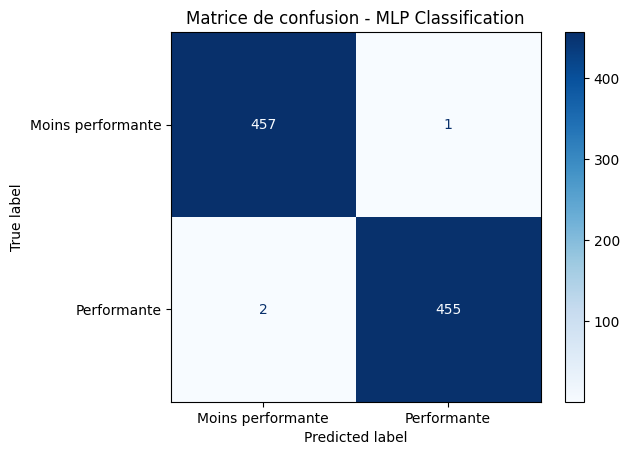

In [114]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_c, y_pred_clf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Moins performante", "Performante"]
)

disp.plot(cmap="Blues")
plt.title("Matrice de confusion - MLP Classification")
plt.show()

Les scores de précision et de rappel sont très élevés pour les deux classes.

Le modèle parvient donc à distinguer avec une excellente fiabilité les campagnes performantes des campagnes moins performantes.

#### Optimisation & Interprétabilité

In [115]:
import pandas as pd

# Importance des variables du Gradient Boosting
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": gb_model.feature_importances_
}).sort_values(by="importance", ascending=False)

importance.head(10)

,feature,importance
0,tv,0.948367
3,total_budget,0.045114
10,sales_per_tv,0.006467
7,tv_radio,0.000022
11,sales_per_radio,0.000009
8,tv_social,0.000005
4,tv_share,0.000004
14,influencer_Micro,0.000003
12,sales_per_social,0.000003
6,social_media_share,0.000003


Les variables les plus influentes pour prédire les ventes sont :

1. `tv`
2. `total_budget`
3. `sales_per_tv`

La variable `tv` domine largement le modèle, ce qui suggère que les investissements publicitaires à la télévision jouent un rôle majeur dans la performance commerciale.

Les autres variables ont un impact beaucoup plus faible.

In [116]:
import shap
print("SHAP disponible")

SHAP disponible


In [117]:
import shap


# Préparation des données pour SHAP
# SHAP nécessite des données strictement numériques.
# On convertit donc les booléens en entiers et on force le format float.

X_train_shap = X_train.copy()
X_test_shap = X_test.copy()

X_train_shap = X_train_shap.astype(float)
X_test_shap = X_test_shap.astype(float)


# Création de l'explainer SHAP pour le modèle Gradient Boosting
explainer = shap.TreeExplainer(gb_model)

# Calcul des valeurs SHAP sur un échantillon du jeu de test
shap_values = explainer.shap_values(X_test_shap.iloc[:100])

print("Valeurs SHAP calculées avec succès.")

Valeurs SHAP calculées avec succès.


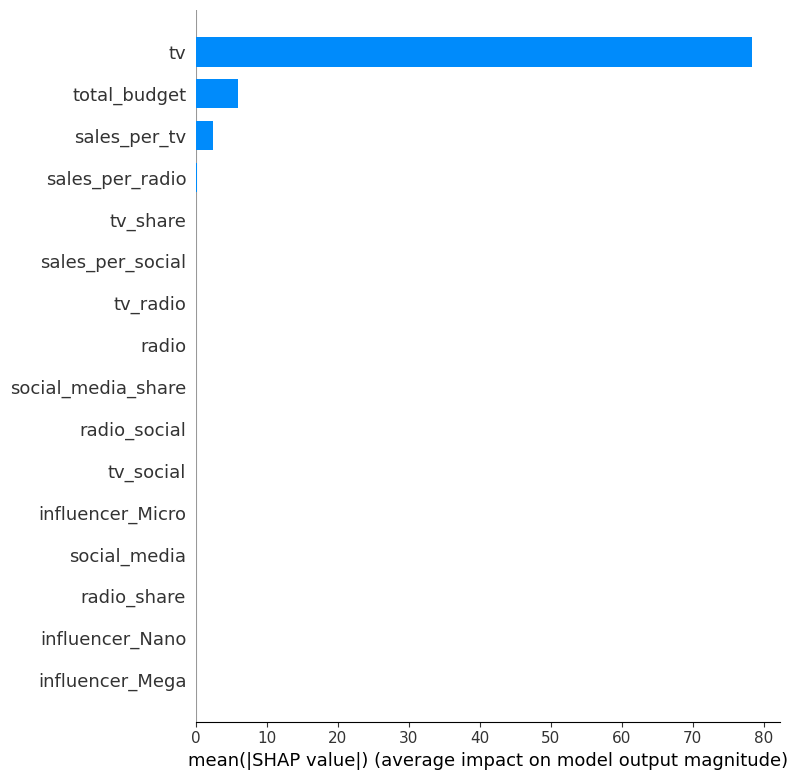

In [118]:
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Visualisation globale de l’importance des variables
# ---------------------------------------------------------

shap.summary_plot(
    shap_values,
    X_test_shap.iloc[:100],
    plot_type="bar"
)

Le graphique SHAP confirme que la variable la plus influente pour prédire les ventes est le budget TV (`tv`).

Les variables `total_budget` et `sales_per_tv` arrivent ensuite, avec un impact nettement plus faible.

Les autres variables contribuent de manière marginale aux prédictions du modèle.

##### Sauvegarde des modèles explicatif et prédicti

In [119]:
import os
import joblib

# Créer le dossier models s'il n'existe pas
os.makedirs("../models", exist_ok=True)

# Sauvegarde du modèle explicable Gradient Boosting
joblib.dump(gb_model, "../models/best_model_gb.pkl")

# Sauvegarde du modèle Deep Learning MLP Régression
mlp_reg.save("../models/best_model_mlp.keras")

print("Gradient Boosting sauvegardé : ../models/best_model_gb.pkl")
print("MLP Regressor sauvegardé : ../models/best_model_mlp.keras")

Gradient Boosting sauvegardé : ../models/best_model_gb.pkl
MLP Regressor sauvegardé : ../models/best_model_mlp.keras


##### Sauvegarde en CSV

In [120]:
os.makedirs("../data/exports", exist_ok=True)

predictions_df = pd.DataFrame({
    "real_sales": y_test.values,
    "predicted_sales_mlp": y_pred_mlp,
    "predicted_sales_gb": y_pred_gb
})

predictions_df.to_csv("../data/exports/model_predictions.csv", index=False)

print("Prédictions sauvegardées : ../data/exports/model_predictions.csv")

Prédictions sauvegardées : ../data/exports/model_predictions.csv
